[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-energy-transition/pypsa-ppa/blob/docs/update-intro-docs/notebooks/pypsa_ppa_example_v1.ipynb)

# PyPSA worked example: modelling a renewable portfolio under a PPA

This notebook shows how **PyPSA** can be used not only for whole-grid studies, but also for a **commercial dispatch** problem: how a renewable portfolio operates when dispatch is optimised against the conditions of a Power Purchase Agreement (PPA).

**PyPSA** (Python for Power System Analysis) is an open-source energy system modelling framework. It represents an energy system, from a single generation site to a national grid, as a network of components connected at **buses**. For a given set of time-series inputs (generation availability, prices, loads), PyPSA finds the least-cost way to operate those components each hour using a linear programme. In this notebook we use that capability to model the hourly commercial dispatch decisions of a renewable portfolio operating under a long-term power supply contract.

---

## What is a Power Purchase Agreement?

A **Power Purchase Agreement (PPA)** is a long-term contract between a power producer and a buyer (the *offtaker*) that sets out the terms under which electricity is sold, including the price, volume, delivery obligations, and what happens when those obligations are not met.

PPAs have become a central instrument in the global energy transition:

- **Enabling renewable project finance.** Developers use PPAs to secure predictable revenue that underpins project debt, reducing the cost of capital for new wind and solar capacity. Without a PPA, a merchant project must absorb the full volatility of wholesale electricity prices, which makes financing harder and more expensive.
- **Supporting corporate clean energy procurement.** Large energy consumers, including data centres, manufacturers and retailers, use PPAs to source renewable electricity at contracted prices, supporting net-zero commitments and RE100 targets.
- **Managing price and volume risk.** PPAs allow both producers and buyers to hedge against spot price volatility. The contract allocates risk between counterparties: who bears the cost of a price spike? Who is exposed if the wind doesn't blow?

### PPA structures vary widely

Not all PPAs work the same way. Key dimensions include:

| Dimension | Common variants |
|---|---|
| **Delivery structure** | Pay-as-produced (variable output), baseload or shaped, 24/7 hourly matched |
| **Settlement** | Physical (direct supply to buyer), virtual / financial (contract-for-difference settled against spot) |
| **Duration** | Short-term (1-5 years) through to long-term (10-20+ years) |
| **Offtake profile** | Flat MW demand, shaped to the buyer's load, or a defined hourly schedule |
| **Balancing obligations** | Who covers shortfall or excess, and at what penalty rate? |

The specific contractual terms, including delivery obligations, allowed shortfall, penalty regimes and market interaction rules, directly shape how a renewable portfolio should be operated. This is where energy system modelling becomes valuable.

---

## Key terms

The following terms appear throughout the notebook. Readers already familiar with renewable energy finance can skip this section.

| Term | Meaning |
|---|---|
| **MW** | Megawatt, a unit of *power* (rate of energy flow at an instant). A 100 MW plant can produce up to 100 MW at any moment if running at full capacity. |
| **MWh** | Megawatt-hour, a unit of *energy* (volume). A 100 MW plant running for one full hour produces 100 MWh. Revenue and costs are almost always expressed per MWh. |
| **MWac** | Megawatt AC, the AC-side output capacity of a solar inverter after converting from DC. The installed DC panel capacity is typically larger. |
| **Capacity factor** | Actual output as a fraction of maximum possible output. A wind farm with a 0.35 capacity factor produces 35% of its rated MW on average. For solar, the capacity factor is zero at night and peaks at midday. |
| **IPP** | Independent Power Producer, a company that owns and operates generation assets and sells electricity, typically under a PPA or into the wholesale market. |
| **Offtaker** | The buyer in a PPA, the party that pays for and receives (or financially settles for) the electricity. |
| **BESS** | Battery Energy Storage System, a large battery co-located with the generation assets, used to store surplus energy and release it when generation is low or prices are favourable. |
| **NEM / AEMO** | National Electricity Market / Australian Energy Market Operator, the wholesale electricity market and its operator in eastern Australia. This notebook uses real NEM spot price and generation data from March 2025. |
| **Spot price** | The real-time wholesale electricity price cleared by the market each dispatch interval. It can spike very high during periods of scarcity and go negative when there is too much generation. |
| **Merchant revenue** | Revenue from selling electricity directly into the spot market at the prevailing spot price, without the protection of a fixed-price contract. Merchant revenue is fully exposed to spot price volatility. |
| **LCOE** | Levelised Cost of Energy, total lifetime costs divided by total lifetime energy generated, expressed in $/MWh. Roughly the minimum average price a project needs to break even. |
| **Tariff** | The contracted price per MWh paid by the offtaker under the PPA, fixed at signing for the duration of the contract. The tariff is a revenue-side figure: it is what the project actually earns per MWh delivered. The LCOE is a cost-side figure: it is what the project needs to earn to recover its capital and operating costs over its lifetime. A project is commercially viable when its PPA tariff exceeds its LCOE, with the margin representing the return to investors. Unlike the spot price, the tariff does not fluctuate, which is what makes it valuable for project finance. |
| **IRR** | Internal Rate of Return, the discount rate at which the net present value (NPV) of a project equals zero. A higher IRR means a better return on the capital invested. |
| **WACC** | Weighted Average Cost of Capital, the blended required return on project debt and equity, used as the discount rate when calculating NPV and LCOE. |

---

## Why model a PPA with PyPSA?

PyPSA is often used to model entire energy grids or grid regions, but it can also be used to model how particular plants would operate under PPAs.

In this framing, we are effectively modelling the **commercial flows of power**. Dispatch is optimised while considering the conditions of the offtake contract.

This is useful for renewable energy plant developers who are building grid-connected plants and intend to sell power under an offtake agreement. PyPSA modelling can then be used to:

- size the plant and storage configuration,
- test dispatch strategies,
- compare PPA structures, and
- run scenario analysis to help quantify merchant and contractual risk.

---

## PyPSA modelling components

Before reading the network design below, it helps to understand the core building blocks PyPSA uses to represent a system:

| Component | What it represents |
|---|---|
| **Bus** | A node where energy must balance each hour, with inflows equal to outflows. In this notebook buses are used as *commercial accounting points*, not physical busbars. |
| **Generator** | A source of power at a bus. Some generators here represent real plant (wind, solar); others are commercial constructs that encode contract terms (penalty, allowed shortfall, market purchase). |
| **Load** | A fixed power demand that must be met each hour. The PPA offtake obligation is modelled as a load. |
| **StorageUnit** | A component that can both absorb and produce power, with a state of charge that carries over between hours. The BESS is modelled as a StorageUnit. |
| **Link** | A directed connection that moves power from one bus to another. Links can carry a `marginal_cost`, positive to discourage use or negative to represent revenue that incentivises the flow. |

The key parameter driving every dispatch decision is **`marginal_cost`**: the optimiser minimises total cost across all components and all hours, so it naturally prefers flows with lower (or more negative) marginal cost. Setting `marginal_cost = -ppa_price` on the PPA delivery link is what makes the model treat PPA delivery as commercially valuable.

---

## Network design used in this notebook

The network includes:

1. **Physical generation and storage assets** represented with generators, storage units, buses and links up to the contractual delivery point.
2. A **PPA offtake load** representing the customer load quantum and hourly profile under the contract.
3. Two **commercial balancing generators** at the PPA delivery bus:
   - **Penalty**: covers unmet PPA demand at a high marginal cost equal to the contractual penalty.
   - **Allowed shortfall**: covers permitted non-delivery at very low marginal cost, but is capped by an aggregate contract constraint.
4. **Market buy and sell components** so the portfolio can interact with the wider market:
   - **Buy from market** represents purchases used to support PPA fulfilment.
   - **Sell to market** represents excess generation sold outside the PPA.
5. **Intermediate buses and links** so the commercial energy flows can be traced and reported clearly.


## Implementation roadmap

This notebook follows these steps:

1. Install the required packages in Colab.
2. Define the worked example and the model variables.
3. Load March 2025 hourly time series from a CSV file placed in a relative `data/` folder.
4. Validate and prepare those time series for the PyPSA model.
5. Build the PyPSA network with buses, generators, storage, loads and links.
6. Validate the network structure and generate a topology diagram with **PyPSATopo**, a package that renders a PyPSA network as a node-and-link diagram, useful for quickly checking that the wiring matches your intent before running the optimisation.
7. Add the PPA SLA constraints using **custom Linopy constraints**. [Linopy](https://linopy.readthedocs.io) is the linear programming library that PyPSA uses under the hood to build and solve the optimisation problem. Accessing it directly via `n.optimize.create_model()` lets us add contract-specific aggregate rules, such as a cap on total shortfall over the month, that cannot be expressed as simple per-component bounds.
8. Solve the model.
9. Check that the contractual constraints are respected.
10. Report operational and commercial results, including charts.

In [1]:

# Colab install cell
# Run this once in Google Colab before executing the rest of the notebook.
%pip install -q pypsa pypsatopo pyarrow highspy


Note: you may need to restart the kernel to use updated packages.



## Worked example scenario

An Independent Power Producer (IPP) is building a small portfolio of assets:

- **150 MW** onshore wind,
- **200 MW AC** solar PV,
- **60 MW / 240 MWh** co-located BESS.

An offtaker offers a PPA to take up to **100 MW in every hour**. The offtaker asks the IPP to meet **75% of that flat 100 MW demand on average over the year**.

The PPA tariff is **\$100/MWh**. Under the PPA, the IPP must pay **1.5x the tariff** for each MWh of shortfall beyond the allowed level. The IPP is allowed to supplement supply with power purchased from the market, subject to an aggregate cap.

For this worked example, we model **one month of hourly data** for **March**.

In [ ]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import SVG, display, Markdown

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Core scenario variables ───────────────────────────────────────────────────
onsw_mw        = 150.0   # onshore wind installed capacity (MW)
pv_mw          = 200.0   # solar PV installed capacity (MWac)
bess_mw        = 60.0    # BESS power capacity (MW)
bess_mwh       = 240.0   # BESS energy capacity (MWh) → 4-hour duration at rated power
bess_max_hours = bess_mwh / bess_mw

ppaload_mw = 100.0   # flat hourly PPA offtake demand (MW)
ppa_price  = 100.0   # PPA tariff ($/MWh)
pen_mult   = 1.5     # shortfall beyond the allowed cap costs pen_mult × ppa_price per MWh

# Contract obligation shares (fractions of total contracted load over the modelled period)
required_delivery_share   = 0.75                          # IPP must deliver ≥ 75% of total PPA load on average
allowed_shortfall_share   = 1 - required_delivery_share   # up to 25% may be undelivered without penalty
market_buy_share          = 0.05                          # aggregate cap on market purchases as share of PPA delivery
scenario_market_buy_share = 0.10                          # scenario-text value; not enforced in the optimisation

# Derived commercial limits
maxbuy_mw     = ppaload_mw                    # hourly market purchase cap ≤ PPA demand
maxsell_mw    = onsw_mw + pv_mw + bess_mw    # max hourly market sale = full portfolio output ceiling
market_spread = 0.10                          # bid-offer spread to prevent zero-cost circular buy-sell flows
chosen_day    = "2025-03-15"                 # representative day used in the single-day operational charts

variables_df = pd.DataFrame([
    ("onsw_mw",                   onsw_mw,                    "MW",    "Onshore wind installed capacity"),
    ("pv_mw",                     pv_mw,                      "MWac",  "Solar PV installed capacity"),
    ("bess_mw",                   bess_mw,                    "MW",    "BESS power capacity"),
    ("bess_mwh",                  bess_mwh,                   "MWh",   "BESS energy capacity"),
    ("bess_max_hours",            bess_max_hours,             "h",     "BESS storage duration"),
    ("bess_efficiency_store",     0.9,                        "–",     "BESS charge efficiency (fraction of energy retained on charge)"),
    ("bess_efficiency_dispatch",  0.9,                        "–",     "BESS dispatch efficiency (fraction of stored energy recovered on discharge)"),
    ("ppaload_mw",                ppaload_mw,                 "MW",    "Hourly PPA offtake load (flat)"),
    ("ppa_price",                 ppa_price,                  "$/MWh", "PPA tariff"),
    ("pen_mult",                  pen_mult,                   "×",     "Penalty multiplier on PPA tariff for shortfall above allowed cap"),
    ("required_delivery_share",   required_delivery_share,    "–",     "Minimum delivery share over the modelled period"),
    ("allowed_shortfall_share",   allowed_shortfall_share,    "–",     "Permitted shortfall share (no penalty up to this level)"),
    ("market_buy_share",          market_buy_share,           "–",     "Aggregate cap on market purchases as share of PPA delivery (implemented)"),
    ("scenario_market_buy_share", scenario_market_buy_share,  "–",     "Scenario-text market purchase value (not used in constrained solve)"),
    ("maxbuy_mw",                 maxbuy_mw,                  "MW",    "Upper bound for BuyFromMarket generator"),
    ("maxsell_mw",                maxsell_mw,                 "MW",    "Upper bound for SellToMarket pathway"),
], columns=["variable", "value", "unit", "description"])

variables_df



## Worked example variables

The code cell above defines all scalar variables used throughout the notebook and displays them in a summary table. They fall into four groups:

**Plant sizing** - `onsw_mw`, `pv_mw`, `bess_mw`, `bess_mwh`, `bess_max_hours`. These set the installed capacities of each asset. A distinction to keep in mind: the BESS has both a *power* capacity (how fast it can charge or discharge, in MW) and an *energy* capacity (how much it can store, in MWh). The ratio `bess_mwh / bess_mw` gives the storage duration, 4 hours at rated power in this scenario, meaning a fully charged battery can deliver 60 MW continuously for 4 hours before it is empty.

**BESS efficiency** - `bess_efficiency_store` and `bess_efficiency_dispatch`. Each charge and discharge cycle loses some energy to heat. With both set to 0.9, the round-trip efficiency is 0.9 × 0.9 = 0.81, meaning that for every 1 MWh put into the battery, only 0.81 MWh comes back out. PyPSA applies these independently: `efficiency_store` scales energy going in; `efficiency_dispatch` scales energy coming out.

**PPA contract terms** - `ppaload_mw`, `ppa_price`, `pen_mult`, `required_delivery_share`, `allowed_shortfall_share`. These encode the key commercial obligations the IPP has agreed to. `ppaload_mw` is the flat hourly demand the offtaker expects (100 MW every hour). `ppa_price` is the contracted tariff (\$100/MWh). `pen_mult` is the penalty multiplier applied to the tariff for each MWh of shortfall beyond the allowed cap (1.5x, so \$150/MWh). `required_delivery_share` and `allowed_shortfall_share` are the flip sides of each other: 75% must be delivered; the remaining 25% may be left undelivered without penalty.

**Market interaction caps** - `market_buy_share`, `maxbuy_mw`, `maxsell_mw`, `market_spread`. These bound the portfolio's interaction with the spot market. `market_buy_share` sets the aggregate cap on market purchases as a fraction of total PPA delivery (5%). `maxbuy_mw` and `maxsell_mw` are the per-hour ceilings for market buy and sell flows. `market_spread` is a small bid-offer spread (0.10 $/MWh) added to the buy price and subtracted from the sell price, which prevents the optimiser from creating zero-cost circular flows between the buy and sell buses.

Time-series variables, such as renewable capacity factors and spot prices, are loaded in the next section from the CSV input file and are not listed here.

In [ ]:
variables_df

## Scenario overview diagrams

The two diagrams below visualise the scenario described above. Run this cell after the variables cell to generate them.

- **Figure 1** shows how the physical assets connect to the IPP aggregation bus and how energy is then routed to the PPA offtaker, the spot market, or absorbed by the penalty / shortfall regime.
- **Figure 2** shows the contractual delivery obligation as a proportion of total contracted load, and where the penalty threshold sits.


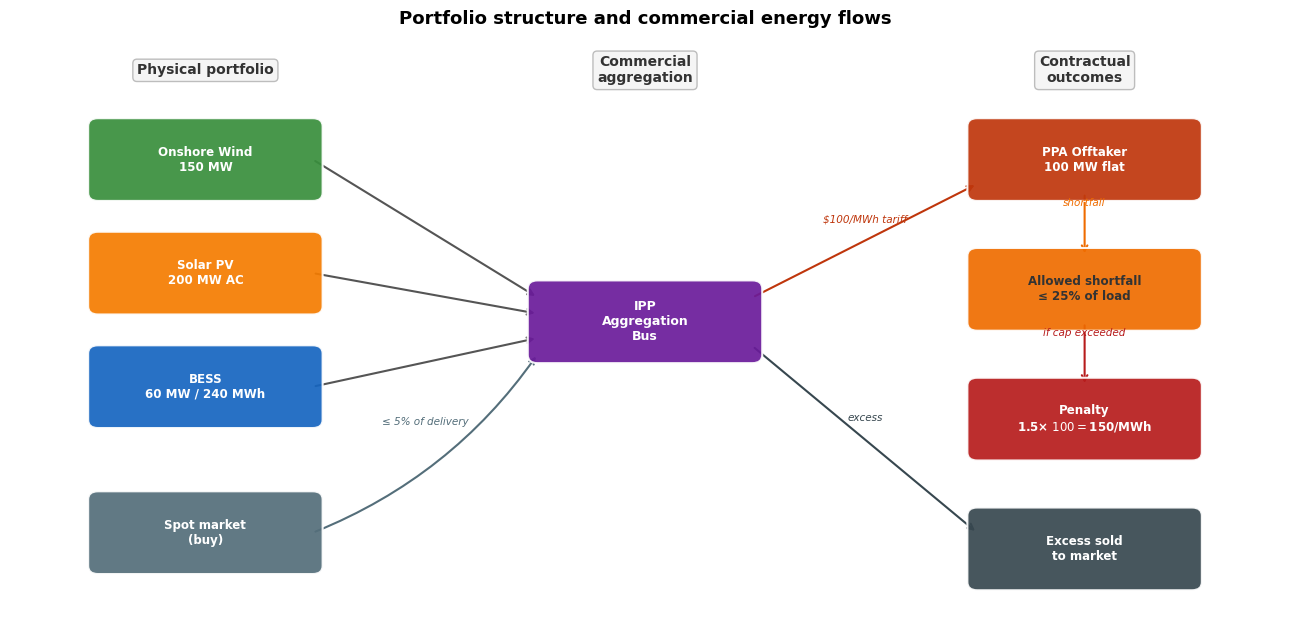

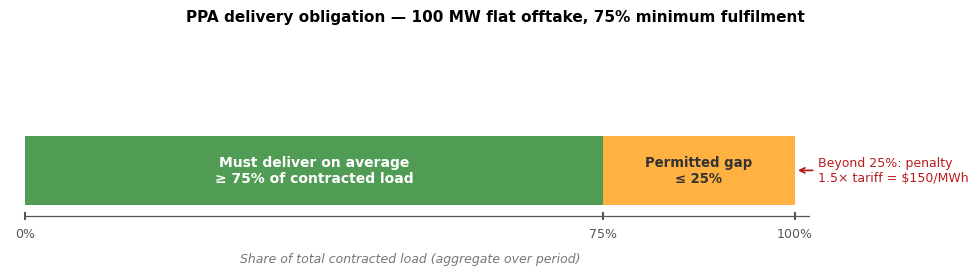

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ── Figure 1: Portfolio structure and commercial flow ─────────────────────────

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_xlim(0, 13)
ax.set_ylim(0.2, 7.5)
ax.axis('off')

BW, BH = 2.2, 0.82

def _box(cx, cy, text, fc, tc='white', fs=8.5):
    ax.add_patch(FancyBboxPatch(
        (cx - BW / 2, cy - BH / 2), BW, BH,
        boxstyle='round,pad=0.1', facecolor=fc, edgecolor='white',
        linewidth=1.5, alpha=0.92, zorder=3,
    ))
    ax.text(cx, cy, text, ha='center', va='center', fontsize=fs,
            color=tc, fontweight='bold', multialignment='center', zorder=4)

def _arrow(x1, y1, x2, y2, label='', lc='#555', rad=0):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), zorder=2,
                arrowprops=dict(arrowstyle='->', color=lc, lw=1.5,
                                connectionstyle=f'arc3,rad={rad}'))
    if label:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx, my + 0.2, label, ha='center', va='bottom',
                fontsize=7.5, color=lc, style='italic')

XA, XM, XR = 2.0, 6.5, 11.0  # column x-positions

# Physical assets (left column)
_box(XA, 6.0, f'Onshore Wind\n{onsw_mw:.0f} MW', '#388E3C')
_box(XA, 4.6, f'Solar PV\n{pv_mw:.0f} MW AC', '#F57C00')
_box(XA, 3.2, f'BESS\n{bess_mw:.0f} MW / {bess_mwh:.0f} MWh', '#1565C0')
_box(XA, 1.4, 'Spot market\n(buy)', '#546E7A')

# IPP aggregation bus (centre)
_box(XM, 4.0, 'IPP\nAggregation\nBus', '#6A1B9A', fs=9)

# Contractual outcomes (right column)
_box(XR, 6.0, f'PPA Offtaker\n{ppaload_mw:.0f} MW flat', '#BF360C')
_box(XR, 4.4, f'Allowed shortfall\n≤ {allowed_shortfall_share * 100:.0f}% of load', '#EF6C00', tc='#333')
_box(XR, 2.8, f'Penalty\n{pen_mult:.1f}× ${ppa_price:.0f} = ${ppa_price * pen_mult:.0f}/MWh', '#B71C1C')
_box(XR, 1.2, 'Excess sold\nto market', '#37474F')

# Assets → aggregation
_arrow(XA + BW / 2, 6.0, XM - BW / 2, 4.3)
_arrow(XA + BW / 2, 4.6, XM - BW / 2, 4.1)
_arrow(XA + BW / 2, 3.2, XM - BW / 2, 3.8)

# Market buy → aggregation (curved to avoid overlap with asset arrows)
_arrow(XA + BW / 2, 1.4, XM - BW / 2, 3.6,
       label=f'≤ {market_buy_share * 100:.0f}% of delivery', lc='#546E7A', rad=0.15)

# Aggregation → PPA delivery
_arrow(XM + BW / 2, 4.3, XR - BW / 2, 5.7,
       label=f'${ppa_price:.0f}/MWh tariff', lc='#BF360C')

# Aggregation → excess market sell
_arrow(XM + BW / 2, 3.7, XR - BW / 2, 1.4,
       label='excess', lc='#37474F')

# Shortfall gap (vertical, right column)
_arrow(XR, 6.0 - BH / 2, XR, 4.4 + BH / 2, label='shortfall', lc='#EF6C00')

# Shortfall → penalty if aggregate cap exceeded
_arrow(XR, 4.4 - BH / 2, XR, 2.8 + BH / 2, label='if cap exceeded', lc='#B71C1C')

# Column headers
for x, txt in [
    (XA, 'Physical portfolio'),
    (XM, 'Commercial\naggregation'),
    (XR, 'Contractual\noutcomes'),
]:
    ax.text(x, 7.1, txt, ha='center', va='center', fontsize=10,
            color='#333', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5', edgecolor='#BDBDBD'))

ax.set_title('Portfolio structure and commercial energy flows', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'portfolio_flow_diagram.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 2: PPA delivery obligation ────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(10, 2.8))
ax2.set_xlim(-2, 114)
ax2.set_ylim(0.3, 3.2)
ax2.axis('off')

BY, BH2 = 1.6, 0.9

ax2.barh(BY, required_delivery_share * 100, height=BH2, left=0,
         color='#388E3C', alpha=0.88)
ax2.barh(BY, allowed_shortfall_share * 100, height=BH2,
         left=required_delivery_share * 100, color='#FFA726', alpha=0.88)

ax2.text(required_delivery_share * 50, BY,
         f'Must deliver on average\n≥ {required_delivery_share * 100:.0f}% of contracted load',
         ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax2.text(required_delivery_share * 100 + allowed_shortfall_share * 50, BY,
         f'Permitted gap\n≤ {allowed_shortfall_share * 100:.0f}%',
         ha='center', va='center', fontsize=9.5, fontweight='bold', color='#333')

ax2.annotate(
    f'Beyond {allowed_shortfall_share * 100:.0f}%: penalty\n'
    f'{pen_mult:.1f}× tariff = ${ppa_price * pen_mult:.0f}/MWh',
    xy=(100, BY), xytext=(103, BY),
    ha='left', va='center', fontsize=9, color='#B71C1C',
    arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.3),
)

tick_y = BY - BH2 / 2 - 0.15
ax2.axhline(tick_y, xmin=0.018, xmax=0.895, color='#555', linewidth=0.9)
for pct, lbl in [
    (0, '0%'),
    (required_delivery_share * 100, f'{required_delivery_share * 100:.0f}%'),
    (100, '100%'),
]:
    ax2.plot(pct, tick_y, '|', color='#555', markersize=6, markeredgewidth=1.5)
    ax2.text(pct, tick_y - 0.28, lbl, ha='center', fontsize=9, color='#555')

ax2.text(50, tick_y - 0.62,
         'Share of total contracted load (aggregate over period)',
         ha='center', fontsize=9, color='#777', style='italic')

fig2.suptitle(
    f'PPA delivery obligation — {ppaload_mw:.0f} MW flat offtake, '
    f'{required_delivery_share * 100:.0f}% minimum fulfilment',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ppa_obligation_diagram.png', dpi=150, bbox_inches='tight')
plt.show()



## Worked example network components

### Buses

| Name | Description |
|---|---|
| `Bus_OnshoreWind` | Onshore wind plant electrical bus |
| `Bus_PVBESS` | Shared PV and BESS electrical bus |
| `Bus_IPPGeneration` | Aggregation bus for portfolio generation before delivery decisions |
| `Bus_BuyFromMarket` | Commercial bus for purchased market energy |
| `Bus_SellToMarket` | Commercial bus for excess energy sold to the market |
| `Bus_PPAOfftake` | Delivery point under the PPA |

### Loads

| Name | bus | `p_set` | Description |
|---|---|---:|---|
| `Load_PPAOfftake` | `Bus_PPAOfftake` | `ppaload_mw` | Contracted hourly offtake load |

### Generators

| Name | bus | `p_nom` | `p_max_pu` | `marginal_cost` | Extra attributes | Description |
|---|---|---:|---|---|---|---|
| `Gen_OnshoreWind` | `Bus_OnshoreWind` | `onsw_mw` | `ts_WindGen` | `0.1` |  | Wind generation asset |
| `Gen_PV` | `Bus_PVBESS` | `pv_mw` | `ts_PVGen` | `0.01` |  | PV generation asset |
| `Gen_BuyFromMarket` | `Bus_BuyFromMarket` | `maxbuy_mw` | `1` | `ts_MktPrice + spread` |  | Market purchases used to support delivery |
| `Gen_SellToMarket` | `Bus_SellToMarket` | `maxsell_mw` | `1` | `-(ts_MktPrice - spread)` | `sign=-1` | Sink representing energy sold to market |
| `Gen_Penalty` | `Bus_PPAOfftake` | `ppaload_mw` | `1` | `ppa_price * pen_mult` |  | Expensive fallback representing penalised shortfall |
| `Gen_AllowedShortfall` | `Bus_PPAOfftake` | `ppaload_mw` | `1` | `0.001` |  | Permitted shortfall, constrained in aggregate |

### Storage units

| Name | bus | `p_nom` | `max_hours` | `efficiency_store` | `efficiency_dispatch` | Description |
|---|---|---:|---:|---:|---:|---|
| `SU_BESS` | `Bus_PVBESS` | `bess_mw` | `4` | `0.9` | `0.9` | Co-located battery at the PV bus |

### Links

| Name | `bus0` | `bus1` | `p_nom` | `marginal_cost` | Description |
|---|---|---|---:|---:|---|
| `OnshoreWind_to_IPPGeneration` | `Bus_OnshoreWind` | `Bus_IPPGeneration` | `onsw_mw` | `0` | Transfers wind output to the portfolio aggregation bus |
| `PVBESS_to_IPPGeneration` | `Bus_PVBESS` | `Bus_IPPGeneration` | `pv_mw + bess_mw` | `0` | Transfers PV and BESS output to the portfolio aggregation bus |
| `BuyFromMarket_to_IPPGeneration` | `Bus_BuyFromMarket` | `Bus_IPPGeneration` | `maxbuy_mw` | `0` | Moves purchased market power into the portfolio account |
| `IPPGen_to_SellToMarket` | `Bus_IPPGeneration` | `Bus_SellToMarket` | `maxsell_mw` | `0` | Routes excess energy to the market sell bus |
| `IPPGen_to_PPAOfftake` | `Bus_IPPGeneration` | `Bus_PPAOfftake` | `ppaload_mw` | `-ppa_price` | Routes delivered energy to the PPA delivery point and carries the contractual value of delivery |

### Design note

The `IPPGen_to_PPAOfftake` link uses `marginal_cost = -ppa_price` so that the optimizer values delivery under the PPA. This is what makes the model behave like a **commercial dispatch** problem rather than a purely physical feasibility problem.


## Load March 2025 hourly input data from CSV

This worked example uses real hourly time series data for **March 2025** sourced from the Australian Energy Market Operator's (AEMO) **National Electricity Market (NEM)**. The data was extracted using the [NEMOSIS](https://github.com/UNSW-CEEM/NEMOSIS) package and covers the **New South Wales (NSW)** dispatch region. Data preparation is documented in the companion notebook `nemosis_march_2025_timeseries_tested.ipynb`.

The CSV is hosted on Google Drive and is downloaded automatically when running in Colab. When running locally, the file is read from `data/march_2025_pypsa_timeseries.csv` at the repository root.

The CSV contains the following required columns:

| Column | Type | Description |
|---|---|---|
| `timestamp` | datetime | Hourly interval start (NEM time, UTC+10) |
| `ts_PVGen` | float (0-1) | Solar PV capacity factor, the fraction of installed capacity available each hour |
| `ts_WindGen` | float (0-1) | Wind capacity factor, the fraction of installed capacity available each hour |
| `ts_NSWPrice` | float ($/MWh) | NSW spot electricity price from the NEM dispatch market |

Any additional columns in the CSV are preserved but are not used by this worked example.

In [ ]:
import sys

GDRIVE_FILE_ID = "1OwB2RJ_aMHeVj2zikKlNcAmt-JDf4_aa"
_csv_dest = DATA_DIR / "march_2025_pypsa_timeseries.csv"

if "google.colab" in sys.modules and not _csv_dest.exists():
    import subprocess
    DATA_DIR.mkdir(exist_ok=True)
    subprocess.run(["gdown", GDRIVE_FILE_ID, "-O", str(_csv_dest)], check=True)
    print(f"Downloaded to {_csv_dest}")

In [ ]:
# Resolve the CSV path, handling two environments:
#   Colab: users upload to a `data/` folder in the working directory
#   Local: the repo keeps data at the repo root `data/` (one level above `notebooks/`)
_candidates = [
    DATA_DIR / "march_2025_pypsa_timeseries.csv",
    Path("../data") / "march_2025_pypsa_timeseries.csv",
]
csv_path = next((p for p in _candidates if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        "Could not find march_2025_pypsa_timeseries.csv. Searched:\n"
        + "\n".join(f"  {p.resolve()}" for p in _candidates)
        + "\nIn Colab, upload the file to a 'data/' folder in the session. "
        "Locally, ensure the file is at data/ in the repository root."
    )

# CSV data is sourced from NEM data reported from AEMO in March 2025,
# and references the preparation notebook `nemosis_march_2025_timeseries_tested.ipynb`.
ts_raw = pd.read_csv(csv_path)

required_columns = ["timestamp", "ts_PVGen", "ts_WindGen", "ts_NSWPrice"]
missing_columns = [col for col in required_columns if col not in ts_raw.columns]
if missing_columns:
    raise ValueError(f"Missing required CSV columns: {missing_columns}")

ts = ts_raw.copy()
ts["timestamp"] = pd.to_datetime(ts["timestamp"])
ts = ts.sort_values("timestamp").set_index("timestamp")
ts.index.name = "snapshot"

# Align market-price naming with the rest of the worked example notebook.
ts["ts_MktPrice"] = ts["ts_NSWPrice"]

# Flat offtake profile retained from the original worked example.
ts["ppaload_mw"] = ppaload_mw

display(Markdown(f"**Loaded input data:** `{csv_path.resolve()}`"))
ts.head()


In [ ]:
# Quick validation charts for the March 2025 input data
fig = px.line(
    ts[["ts_WindGen", "ts_PVGen"]].reset_index().melt(id_vars="snapshot", var_name="series", value_name="value"),
    x="snapshot",
    y="value",
    color="series",
    title="March 2025 renewable availability profiles from CSV",
)
fig.update_layout(yaxis_title="Availability (p_max_pu)")
fig.show()

fig = px.line(
    ts.reset_index(),
    x="snapshot",
    y="ts_MktPrice",
    title="March 2025 NSW market price profile from CSV",
)
fig.update_layout(yaxis_title="$/MWh")
fig.show()


## Review the prepared time series

The charts above show the raw input data. A few things to look for:

**Renewable availability profiles**: both `ts_WindGen` and `ts_PVGen` are capacity factors (0-1). PyPSA multiplies each by `p_nom` to get the maximum available output in MW each hour. Wind has broad availability across the day; solar is strictly zero at night and peaks around midday. Hours where both profiles are simultaneously low are the stress cases for PPA delivery, where the model must draw on BESS or tolerate shortfall.

**NSW spot price**: prices can spike sharply (up to ~\$3,200/MWh in March 2025) during demand peaks or generation shortfalls, and go negative during oversupply. The model will strongly avoid market purchases during high-price hours and may sell excess generation at a loss during negative-price hours if curtailment is the only alternative.

**Statistical summary**: the `describe()` table below confirms the distribution of each series. Key figures to note:
- Wind capacity factor mean ≈ 0.37, PV mean ≈ 0.22 for March
- Market price mean ≈ \$90/MWh with high standard deviation, reflecting the volatile NEM price environment
- `ppaload_mw` is flat at 100 MW across all 744 hours, as expected

In [ ]:
# Confirm the modelling dataset
ts.describe(include='all').T


## Create the PyPSA network

This cell builds the optimisation model topology. The network represents the **commercial energy flows** of the IPP portfolio rather than physical grid connections; each bus, generator, and link is chosen so that the optimizer's dispatch decisions reflect the contractual economics of the PPA.

Key design choices made here:

- **Separate buses** for each commercial flow path (wind, PV+BESS, market buy, market sell, PPA delivery) allow results to be cleanly extracted per source, and prevent the optimizer exploiting degenerate circular flows.
- **`Gen_SellToMarket`** uses `sign=-1` so it acts as a sink at its bus, following the PyPSA convention for a component that consumes energy rather than producing it.
- **`IPPGen_to_PPAOfftake`** carries `marginal_cost = -ppa_price`, meaning the optimizer *earns revenue* by dispatching through this link. This is what makes PPA delivery commercially preferable to market sales.
- **`Gen_Penalty`** and **`Gen_AllowedShortfall`** sit at `Bus_PPAOfftake` to balance the PPA load when the portfolio cannot deliver. Their cost structure encodes the contractual shortfall regime: near-zero for the permitted gap, 1.5x the tariff for anything beyond it.

In [ ]:
import pypsa

n = pypsa.Network()
n.set_snapshots(ts.index)

# ── Buses ─────────────────────────────────────────────────────────────────────
# Each bus is a distinct commercial accounting point. Separate buy and sell buses
# prevent the optimizer creating zero-cost circular flows between market components.
for bus_name in [
    "Bus_OnshoreWind",
    "Bus_PVBESS",
    "Bus_IPPGeneration",
    "Bus_BuyFromMarket",
    "Bus_SellToMarket",
    "Bus_PPAOfftake",
]:
    n.add("Bus", bus_name)

# ── Load ──────────────────────────────────────────────────────────────────────
# The PPA offtake is a fixed load at the delivery bus. Every hour the optimizer
# must balance it using portfolio delivery, allowed shortfall, or penalised shortfall.
n.add(
    "Load",
    "Load_PPAOfftake",
    bus="Bus_PPAOfftake",
    p_set=ts["ppaload_mw"],
)

# ── Generators ────────────────────────────────────────────────────────────────
n.add(
    "Generator",
    "Gen_OnshoreWind",
    bus="Bus_OnshoreWind",
    p_nom=onsw_mw,
    p_max_pu=ts["ts_WindGen"],   # capacity factor limits output to ts_WindGen × p_nom each hour
    marginal_cost=0.1,           # near-zero cost keeps wind preferred over market purchases
)

n.add(
    "Generator",
    "Gen_PV",
    bus="Bus_PVBESS",
    p_nom=pv_mw,
    p_max_pu=ts["ts_PVGen"],
    marginal_cost=0.01,
)

n.add(
    "Generator",
    "Gen_BuyFromMarket",
    bus="Bus_BuyFromMarket",
    p_nom=maxbuy_mw,
    p_max_pu=1.0,
    marginal_cost=ts["ts_MktPrice"] + market_spread,  # pay spot price plus a small spread
)

# sign=-1 makes Gen_SellToMarket act as a load (sink) at Bus_SellToMarket.
# The negative marginal cost represents revenue: the optimizer earns (MktPrice - spread)
# for each MWh routed to this bus.
n.add(
    "Generator",
    "Gen_SellToMarket",
    bus="Bus_SellToMarket",
    p_nom=maxsell_mw,
    p_max_pu=1.0,
    sign=-1.0,
    marginal_cost=-(ts["ts_MktPrice"] - market_spread),
)

# Gen_Penalty covers unmet PPA demand at 1.5× the tariff. Its high cost means the
# optimizer only uses it after exhausting the cheaper Gen_AllowedShortfall allowance.
n.add(
    "Generator",
    "Gen_Penalty",
    bus="Bus_PPAOfftake",
    p_nom=ppaload_mw,
    p_max_pu=1.0,
    marginal_cost=ppa_price * pen_mult,
)

# Gen_AllowedShortfall covers permitted non-delivery at near-zero cost.
# Its aggregate volume is capped by a custom constraint added in the next step.
n.add(
    "Generator",
    "Gen_AllowedShortfall",
    bus="Bus_PPAOfftake",
    p_nom=ppaload_mw,
    p_max_pu=1.0,
    marginal_cost=0.001,
)

# ── Storage ───────────────────────────────────────────────────────────────────
n.add(
    "StorageUnit",
    "SU_BESS",
    bus="Bus_PVBESS",
    p_nom=bess_mw,
    max_hours=bess_max_hours,
    efficiency_store=0.9,
    efficiency_dispatch=0.9,
    cyclic_state_of_charge=True,  # BESS ends March with the same SOC it started with
    marginal_cost=0.0,
)

# ── Links ─────────────────────────────────────────────────────────────────────
# Links transfer power between buses at 100% efficiency.
# IPPGen_to_PPAOfftake uses marginal_cost = -ppa_price so the optimizer earns
# the PPA tariff for each MWh dispatched to the offtaker — the key incentive
# that makes PPA delivery commercially preferable to market sales.
link_defs = [
    ("OnshoreWind_to_IPPGeneration",   "Bus_OnshoreWind",   "Bus_IPPGeneration", onsw_mw,         0.0),
    ("PVBESS_to_IPPGeneration",        "Bus_PVBESS",        "Bus_IPPGeneration", pv_mw + bess_mw, 0.0),
    ("BuyFromMarket_to_IPPGeneration", "Bus_BuyFromMarket", "Bus_IPPGeneration", maxbuy_mw,       0.0),
    ("IPPGen_to_SellToMarket",         "Bus_IPPGeneration", "Bus_SellToMarket",  maxsell_mw,      0.0),
    ("IPPGen_to_PPAOfftake",           "Bus_IPPGeneration", "Bus_PPAOfftake",    ppaload_mw,      -ppa_price),
]

for name, bus0, bus1, p_nom, marginal_cost in link_defs:
    n.add(
        "Link",
        name,
        bus0=bus0,
        bus1=bus1,
        p_nom=p_nom,
        efficiency=1.0,
        marginal_cost=marginal_cost,
    )

n.consistency_check()
print(n)


## Generate a topology diagram with PyPSATopo

[PyPSATopo](https://github.com/davide-f/pypsatopo) generates network topology diagrams directly from a PyPSA network object, visualising all buses, generators, storage units, and links. It is useful as a quick sanity check on the model wiring before running the optimisation.

The diagram below shows all six buses and the connections between them. Things to verify:

- The three generation assets (wind, PV, BESS) each connect via their own intermediate bus before aggregating at `Bus_IPPGeneration`.
- Market buy and sell paths use separate buses — this prevents the optimizer creating zero-cost circular flows.
- `Gen_Penalty` and `Gen_AllowedShortfall` sit at `Bus_PPAOfftake`, where they balance the PPA load when the portfolio cannot fully deliver.


In [ ]:
# TODO: investigate whether PyPSATopo supports colour-coding PPA-related elements.

import pypsatopo

topo_file = OUTPUT_DIR / "ppa_network_topology.svg"
pypsatopo.generate(n, file_output=str(topo_file), file_format="svg")
print(f"Saved topology diagram to: {topo_file.resolve()}")
display(SVG(filename=str(topo_file)))


## Add the PPA SLA constraints

We add two custom constraints using PyPSA's Linopy-backed model API:

1. **Allowed shortfall cap**: total generation from `Gen_AllowedShortfall` must be no more than **25%** of total PPA load over the modelled period.
2. **Market buy cap**: total generation from `Gen_BuyFromMarket` must be no more than **5%** of total energy delivered through `IPPGen_to_PPAOfftake`.

This follows the recommended workflow of creating the model first with `n.optimize.create_model()`, adding constraints via `m.add_constraints(...)`, and then solving with `n.optimize.solve_model()`. PyPSA documents this pattern in its [optimization documentation](https://pypsa.readthedocs.io/en/latest/user-guide/optimal-power-flow.html).


In [ ]:
# n.optimize.create_model() builds the Linopy LP problem from the network without
# solving it, so we can inject custom constraints before handing off to the solver.
m = n.optimize.create_model()

# Variable arrays indexed by (snapshot, component name).
gen_p  = m.variables["Generator-p"]
link_p = m.variables["Link-p"]

# Total contracted PPA load over the modelled period (scalar, MWh).
total_load_mwh = float(n.loads_t.p_set["Load_PPAOfftake"].sum())

# Constraint 1 — allowed shortfall cap
# Sum Gen_AllowedShortfall across all snapshots ≤ 25% of total load.
# Without this, Gen_AllowedShortfall's near-zero marginal cost would cause the
# optimizer to never deliver to the PPA at all.
allowed_shortfall_expr = gen_p.loc[:, "Gen_AllowedShortfall"].sum()
m.add_constraints(
    allowed_shortfall_expr <= allowed_shortfall_share * total_load_mwh,
    name="AllowedShortfall_Limit",
)

# Constraint 2 — market buy cap
# Aggregate market purchases ≤ 5% of total PPA delivery.
# This is a relative constraint: buy_total ≤ market_buy_share × delivery_total,
# expressed as a linear inequality between two sums of decision variables.
buy_from_market_expr = gen_p.loc[:, "Gen_BuyFromMarket"].sum()
ppa_delivery_expr    = link_p.loc[:, "IPPGen_to_PPAOfftake"].sum()
m.add_constraints(
    buy_from_market_expr <= market_buy_share * ppa_delivery_expr,
    name="BuyFromMarket_Limit",
)

print(m)


In [17]:

# Solve the model
status, condition = n.optimize.solve_model(solver_name="highs")
print("Solver status:", status)
print("Termination condition:", condition)


Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 197.03it/s]


Solver status: ok
Termination condition: optimal


## Results

The cells below extract and summarise the optimised dispatch for March 2025.

- **`total_load_mwh`** - total contracted PPA obligation (100 MW × 744 h = 74,400 MWh).
- **`ppa_delivered_mwh`** - volume actually delivered to the offtaker; should reach exactly the 75% minimum (55,800 MWh) since the model has no incentive to over-deliver once the constraint is met.
- **`allowed_shortfall_mwh`** - permitted non-delivery; will be at most 25% of total load. The model exhausts this allowance before triggering the penalty generator.
- **`penalty_mwh`** - volume incurring the contractual penalty; should be zero for a well-configured portfolio.
- **`sold_to_market_mwh`** - generation sold into the spot market rather than directed to the PPA.

Revenue is reported separately after the dispatch summary.

In [ ]:
# Extract useful series from the solved network
wind_gen         = n.generators_t.p["Gen_OnshoreWind"]
pv_gen           = n.generators_t.p["Gen_PV"]
market_buy       = n.generators_t.p["Gen_BuyFromMarket"]
allowed_shortfall = n.generators_t.p["Gen_AllowedShortfall"]
penalty_gen      = n.generators_t.p["Gen_Penalty"]
market_sell      = n.generators_t.p["Gen_SellToMarket"]

bess_dispatch = n.storage_units_t.p_dispatch["SU_BESS"]
bess_store    = n.storage_units_t.p_store["SU_BESS"]
soc           = n.storage_units_t.state_of_charge["SU_BESS"]

# For links, p1 is negative when supplying to bus1 — negate to get positive delivered flow.
ppa_delivery      = -n.links_t.p1["IPPGen_to_PPAOfftake"]
sell_link_flow    = -n.links_t.p1["IPPGen_to_SellToMarket"]
buy_link_flow     = -n.links_t.p1["BuyFromMarket_to_IPPGeneration"]

renewable_and_storage_to_ppa = (ppa_delivery - market_buy).clip(lower=0)

summary = {
    "total_load_mwh":                    float(ts["ppaload_mw"].sum()),
    "ppa_delivered_mwh":                 float(ppa_delivery.sum()),
    "renewable_and_storage_to_ppa_mwh":  float(renewable_and_storage_to_ppa.sum()),
    "market_buy_to_ppa_mwh":             float(market_buy.sum()),
    "allowed_shortfall_mwh":             float(allowed_shortfall.sum()),
    "penalty_mwh":                       float(penalty_gen.sum()),
    "sold_to_market_mwh":                float(market_sell.sum()),
    "wind_generation_mwh":               float(wind_gen.sum()),
    "pv_generation_mwh":                 float(pv_gen.sum()),
    "bess_dispatch_mwh":                 float(bess_dispatch.sum()),
    "bess_charge_mwh":                   float(bess_store.sum()),
}

summary["fulfilled_share"]                  = summary["ppa_delivered_mwh"] / summary["total_load_mwh"]
summary["allowed_shortfall_share_actual"]   = summary["allowed_shortfall_mwh"] / summary["total_load_mwh"]
summary["buy_share_of_ppa_delivery"]        = (
    summary["market_buy_to_ppa_mwh"] / summary["ppa_delivered_mwh"]
    if summary["ppa_delivered_mwh"] > 0 else np.nan
)
summary["penalty_share_of_load"]            = summary["penalty_mwh"] / summary["total_load_mwh"]
summary["excess_share_of_total_generation"] = (
    summary["sold_to_market_mwh"] /
    (summary["wind_generation_mwh"] + summary["pv_generation_mwh"] + summary["bess_dispatch_mwh"])
)

# Formatted dispatch summary
results_display = pd.DataFrame([
    ("Total PPA load",                  f"{summary['total_load_mwh']:,.0f} MWh",  "100 MW × 744 h"),
    ("PPA delivered",                   f"{summary['ppa_delivered_mwh']:,.0f} MWh", f"{summary['fulfilled_share']:.1%} of total load"),
    ("  › renewable & storage",         f"{summary['renewable_and_storage_to_ppa_mwh']:,.0f} MWh", ""),
    ("  › purchased from market",       f"{summary['market_buy_to_ppa_mwh']:,.0f} MWh", f"{summary['buy_share_of_ppa_delivery']:.1%} of delivery"),
    ("Allowed shortfall (undelivered)", f"{summary['allowed_shortfall_mwh']:,.0f} MWh", f"{summary['allowed_shortfall_share_actual']:.1%} of total load"),
    ("Penalty volume",                  f"{summary['penalty_mwh']:,.0f} MWh",     f"{summary['penalty_share_of_load']:.1%} of total load"),
    ("Sold to spot market",             f"{summary['sold_to_market_mwh']:,.0f} MWh", f"{summary['excess_share_of_total_generation']:.1%} of total generation"),
    ("Wind generation",                 f"{summary['wind_generation_mwh']:,.0f} MWh", ""),
    ("PV generation",                   f"{summary['pv_generation_mwh']:,.0f} MWh",  ""),
    ("BESS dispatch",                   f"{summary['bess_dispatch_mwh']:,.0f} MWh",  ""),
    ("BESS charge",                     f"{summary['bess_charge_mwh']:,.0f} MWh",    ""),
], columns=["metric", "volume", "note"])
results_display


In [ ]:
# Verify that both custom constraints were respected in the optimal solution.
# For this scenario the solver should bind exactly on both limits (actual = limit),
# but we check with a small floating-point tolerance to guard against solver noise.
allowed_shortfall_limit = allowed_shortfall_share * total_load_mwh
buy_limit = market_buy_share * summary["ppa_delivered_mwh"]

checks = pd.DataFrame(
    {
        "metric": [
            "Allowed shortfall actual (MWh)",
            "Allowed shortfall limit (MWh)",
            "Buy from market actual (MWh)",
            "Buy from market limit (MWh)",
        ],
        "value": [
            summary["allowed_shortfall_mwh"],
            allowed_shortfall_limit,
            summary["market_buy_to_ppa_mwh"],
            buy_limit,
        ],
    }
)
checks


In [20]:

# Explicit assertions so the notebook fails loudly if the constraints are violated
assert summary["allowed_shortfall_mwh"] <= allowed_shortfall_limit + 1e-6
assert summary["market_buy_to_ppa_mwh"] <= buy_limit + 1e-6
print("Constraint checks passed.")


Constraint checks passed.


In [ ]:
# Revenue breakdown
ppa_revenue           = summary["ppa_delivered_mwh"] * ppa_price
excess_revenue        = float((market_sell * ts["ts_MktPrice"]).sum())
market_purchase_cost  = float((market_buy  * ts["ts_MktPrice"]).sum())
penalty_cost          = summary["penalty_mwh"] * ppa_price * pen_mult
net_revenue           = ppa_revenue + excess_revenue - market_purchase_cost - penalty_cost

commercials = pd.DataFrame(
    {
        "metric": [
            "PPA revenue",
            "Excess merchant revenue",
            "Market purchase cost",
            "Penalty cost",
            "Net revenue (after purchases and penalties)",
        ],
        "value": [
            f"${ppa_revenue:>12,.0f}",
            f"${excess_revenue:>12,.0f}",
            f"${market_purchase_cost:>12,.0f}",
            f"${penalty_cost:>12,.0f}",
            f"${net_revenue:>12,.0f}",
        ],
        "note": [
            f"{summary['ppa_delivered_mwh']:,.0f} MWh × ${ppa_price:.0f}/MWh",
            f"{summary['sold_to_market_mwh']:,.0f} MWh at spot prices",
            f"{summary['market_buy_to_ppa_mwh']:,.0f} MWh at spot prices",
            f"{summary['penalty_mwh']:,.0f} MWh × ${ppa_price * pen_mult:.0f}/MWh",
            "",
        ],
    }
)
commercials


## Key statistics

The table below summarises the headline KPIs from the optimised dispatch, grouped into four areas: generation performance, BESS utilisation, PPA delivery, and revenue split. These are the metrics most useful for comparing scenarios or assessing portfolio performance against the contract.


In [ ]:
n_hours       = len(ts)
total_gen_mwh = (
    summary["wind_generation_mwh"]
    + summary["pv_generation_mwh"]
    + summary["bess_dispatch_mwh"]
)

# ── Generation capacity factors ───────────────────────────────────────────────
wind_cf = summary["wind_generation_mwh"] / (onsw_mw * n_hours)
pv_cf   = summary["pv_generation_mwh"]   / (pv_mw   * n_hours)
bess_cf = summary["bess_dispatch_mwh"]   / (bess_mw  * n_hours)

# ── BESS utilisation ──────────────────────────────────────────────────────────
bess_equiv_cycles = summary["bess_dispatch_mwh"] / bess_mwh
bess_charge_hrs   = int((bess_store    > 0.01).sum())
bess_dispatch_hrs = int((bess_dispatch > 0.01).sum())
avg_soc           = float(soc.mean())

# ── Revenue split ─────────────────────────────────────────────────────────────
_ppa_rev      = summary["ppa_delivered_mwh"] * ppa_price
_merchant_rev = float((market_sell * ts["ts_MktPrice"]).sum())
_buy_cost     = float((market_buy  * ts["ts_MktPrice"]).sum())
_total_net    = _ppa_rev + _merchant_rev - _buy_cost

effective_capture_price = _total_net / total_gen_mwh

kpi_df = pd.DataFrame([
    # Generation
    ("Wind capacity factor",             f"{wind_cf:.1%}",    f"{summary['wind_generation_mwh']:,.0f} MWh"),
    ("PV capacity factor",               f"{pv_cf:.1%}",      f"{summary['pv_generation_mwh']:,.0f} MWh"),
    ("BESS dispatch capacity factor",    f"{bess_cf:.1%}",    f"{summary['bess_dispatch_mwh']:,.0f} MWh dispatched"),
    ("Total generation",                 f"{total_gen_mwh:,.0f} MWh", ""),
    # BESS
    ("BESS equivalent full cycles",      f"{bess_equiv_cycles:.1f}",  f"over {n_hours} h ({bess_mwh:.0f} MWh per cycle)"),
    ("BESS hours charging",              f"{bess_charge_hrs} h",       f"{bess_charge_hrs / n_hours:.1%} of period"),
    ("BESS hours dispatching",           f"{bess_dispatch_hrs} h",     f"{bess_dispatch_hrs / n_hours:.1%} of period"),
    ("BESS average state of charge",     f"{avg_soc:.1f} MWh",         f"{avg_soc / bess_mwh:.1%} of capacity"),
    # PPA delivery
    ("PPA fulfilment rate",              f"{summary['fulfilled_share']:.1%}",
     f"{summary['ppa_delivered_mwh']:,.0f} / {summary['total_load_mwh']:,.0f} MWh"),
    ("Shortfall allowance used",
     f"{summary['allowed_shortfall_share_actual'] / allowed_shortfall_share:.1%}",
     f"{summary['allowed_shortfall_mwh']:,.0f} MWh of {allowed_shortfall_share * summary['total_load_mwh']:,.0f} MWh cap"),
    ("Penalty volume",                   f"{summary['penalty_mwh']:,.0f} MWh",
     f"{summary['penalty_share_of_load']:.1%} of total load"),
    # Revenue
    ("PPA share of net revenue",         f"{_ppa_rev / _total_net:.1%}",      f"${_ppa_rev:,.0f}"),
    ("Merchant share of net revenue",    f"{_merchant_rev / _total_net:.1%}", f"${_merchant_rev:,.0f}"),
    ("Market purchase cost share",       f"{summary['buy_share_of_ppa_delivery']:.1%} of delivery",
     f"${_buy_cost:,.0f}"),
    ("Effective net capture price",      f"${effective_capture_price:.2f}/MWh",
     "net revenue ÷ total generation"),
], columns=["metric", "value", "detail"])

kpi_df


In [ ]:
# Average supply mix by hour of day across March.
# Positive bars show where energy comes from; the dashed line marks the PPA demand
# level (100 MW). Hours where the stacked positive bars fall below this line are
# hours that rely on allowed shortfall to balance the PPA load on average.
# BESS charging (negative values, right axis) is plotted separately so it does not
# compress the generation bars — it represents energy drawn from PV to charge the battery.

pv_direct = pv_gen - bess_store

source_df = pd.DataFrame(
    {
        "Wind": wind_gen,
        "PV (direct discharge)": pv_direct,
        "BESS discharge": bess_dispatch,
        "Buy from market": market_buy,
        "BESS charging": -bess_store,
    },
    index=ts.index,
)

source_df["hour"] = source_df.index.hour
avg_24h = source_df.groupby("hour").mean().reset_index()

positive_cols = ["Wind", "PV (direct discharge)", "BESS discharge", "Buy from market"]
negative_col = "BESS charging"

y_abs_max = max(
    avg_24h[positive_cols].sum(axis=1).max(),
    avg_24h[negative_col].abs().max(),
)
y_abs_max = float(y_abs_max * 1.05) if y_abs_max > 0 else 1.0

fig = go.Figure()

for col in positive_cols:
    fig.add_trace(
        go.Bar(x=avg_24h["hour"], y=avg_24h[col], name=col, yaxis="y")
    )

fig.add_trace(
    go.Bar(x=avg_24h["hour"], y=avg_24h[negative_col], name=negative_col, yaxis="y2")
)

fig.add_hline(
    y=ppaload_mw,
    line_dash="dash",
    line_color="#333333",
    line_width=1.5,
    annotation_text=f"PPA demand ({ppaload_mw:.0f} MW)",
    annotation_position="top right",
    annotation_font_size=9,
)

fig.update_layout(
    title="Average hourly supply mix across March",
    barmode="relative",
    xaxis_title="Hour of day",
    yaxis=dict(
        title="Average MW (supply to PPA / market)",
        range=[-y_abs_max, y_abs_max],
    ),
    yaxis2=dict(
        title="Average MW (BESS charging)",
        overlaying="y",
        side="right",
        range=[-y_abs_max, y_abs_max],
        matches="y",
        showgrid=False,
        zeroline=False,
    ),
    legend_title="Source",
)

fig.show()


In [ ]:
# Actual supply mix for a chosen representative day.
# The dashed line marks the PPA demand level (100 MW): hours where the positive
# bars fall below it used allowed shortfall to balance the PPA load.
# BESS charging (negative, right axis) shows when the battery was absorbing
# surplus PV generation rather than dispatching to the PPA or market.

chosen = source_df.loc[chosen_day].copy()
chosen = chosen.reset_index().rename(columns={"snapshot": "time"})

positive_cols = ["Wind", "PV (direct discharge)", "BESS discharge", "Buy from market"]
negative_col = "BESS charging"

y_abs_max = max(
    chosen[positive_cols].sum(axis=1).max(),
    chosen[negative_col].abs().max(),
)
y_abs_max = float(y_abs_max * 1.05) if y_abs_max > 0 else 1.0

fig = go.Figure()

for col in positive_cols:
    fig.add_trace(
        go.Bar(x=chosen["time"], y=chosen[col], name=col, yaxis="y")
    )

fig.add_trace(
    go.Bar(x=chosen["time"], y=chosen[negative_col], name=negative_col, yaxis="y2")
)

fig.add_hline(
    y=ppaload_mw,
    line_dash="dash",
    line_color="#333333",
    line_width=1.5,
    annotation_text=f"PPA demand ({ppaload_mw:.0f} MW)",
    annotation_position="top right",
    annotation_font_size=9,
)

fig.update_layout(
    title=f"Actual hourly supply mix for {chosen_day}",
    barmode="relative",
    xaxis_title="Time",
    yaxis=dict(
        title="MW (supply to PPA / market)",
        range=[-y_abs_max, y_abs_max],
    ),
    yaxis2=dict(
        title="MW (BESS charging)",
        overlaying="y",
        side="right",
        range=[-y_abs_max, y_abs_max],
        matches="y",
        showgrid=False,
        zeroline=False,
    ),
    legend_title="Source",
)

fig.show()


In [ ]:
# Hourly operational detail for the chosen day.
# PPA delivery and shortfall should sum to ppaload_mw each hour.
# BESS state of charge is in MWh (max = bess_mwh = 240 MWh).
ops_day = pd.DataFrame(
    {
        "PPA delivery (MW)":      ppa_delivery.loc[chosen_day].round(1),
        "Sell to market (MW)":    market_sell.loc[chosen_day].round(1),
        "Allowed shortfall (MW)": allowed_shortfall.loc[chosen_day].round(1),
        "Penalty (MW)":           penalty_gen.loc[chosen_day].round(1),
        "BESS state of charge (MWh)": soc.loc[chosen_day].round(1),
    }
)
ops_day.head()


## Quick financial analysis

This section provides a high-level pre-tax, ungeared financial assessment of the portfolio based on the March dispatch results scaled to a full year.

**Caveats:** March is a single month and may not represent annual averages, as wind and solar seasonality, price volatility, and dispatch patterns all vary across the year. Treat the annualised figures as indicative order-of-magnitude estimates only. The analysis excludes financing costs, tax, depreciation, and connection or transmission charges.

The code below is structured in four blocks:

1. **CAPEX and OPEX** - capital cost assumptions per technology and annual operating cost.
2. **Annualised cashflows** - March dispatch results scaled to a full year using `8760 / 744`.
3. **LCOE, IRR, NPV** - standard project finance metrics at the specified discount rate.
4. **PPA price discovery** - the breakeven PPA tariff required to achieve a target IRR, solved analytically using the annuity formula.

In [ ]:
from scipy.optimize import brentq

# ── Financial assumptions — edit these to explore scenarios ───────────────────
wind_capex_per_kw   = 1_800   # $/kW installed
pv_capex_per_kw     = 1_000   # $/kW installed
bess_capex_per_kwh  =   500   # $/kWh storage capacity
opex_rate           =  0.02   # annual OPEX as fraction of total CAPEX
project_life_yrs    =    25   # project lifetime (years)
discount_rate       =  0.08   # WACC used for LCOE and NPV
target_irr          =  0.10   # target IRR for PPA price discovery

# ── CAPEX and annual OPEX ─────────────────────────────────────────────────────
capex_wind  = wind_capex_per_kw  * onsw_mw  * 1_000
capex_pv    = pv_capex_per_kw   * pv_mw    * 1_000
capex_bess  = bess_capex_per_kwh * bess_mwh * 1_000
capex_total = capex_wind + capex_pv + capex_bess
annual_opex = capex_total * opex_rate

# ── Annualise March dispatch results ─────────────────────────────────────────
# Scale March figures to a full year. March = 744 h; full year = 8,760 h.
# Treat as indicative — March may not represent annual averages.
n_hrs_march  = len(ts)
ann          = 8_760 / n_hrs_march

annual_ppa_vol   = summary["ppa_delivered_mwh"]    * ann
annual_merch_mwh = summary["sold_to_market_mwh"]   * ann
annual_buy_mwh   = summary["market_buy_to_ppa_mwh"] * ann
annual_gen_mwh   = (
    summary["wind_generation_mwh"]
    + summary["pv_generation_mwh"]
    + summary["bess_dispatch_mwh"]
) * ann

# March-average prices for market components
_merch_rev_m  = float((market_sell * ts["ts_MktPrice"]).sum())
_buy_cost_m   = float((market_buy  * ts["ts_MktPrice"]).sum())
avg_merch_px  = _merch_rev_m / summary["sold_to_market_mwh"]   if summary["sold_to_market_mwh"]   > 0 else 0.0
avg_buy_px    = _buy_cost_m  / summary["market_buy_to_ppa_mwh"] if summary["market_buy_to_ppa_mwh"] > 0 else 0.0

annual_ppa_rev   = annual_ppa_vol   * ppa_price
annual_merch_rev = annual_merch_mwh * avg_merch_px
annual_buy_cost  = annual_buy_mwh   * avg_buy_px
annual_net_rev   = annual_ppa_rev + annual_merch_rev - annual_buy_cost

# ── LCOE ──────────────────────────────────────────────────────────────────────
annuity = (1 - (1 + discount_rate) ** -project_life_yrs) / discount_rate
lcoe    = (capex_total / annuity + annual_opex) / annual_gen_mwh

# ── NPV and IRR ───────────────────────────────────────────────────────────────
annual_cf = annual_net_rev - annual_opex
cashflows = [-capex_total] + [annual_cf] * project_life_yrs

def _npv(rate, cfs=cashflows):
    return sum(cf / (1 + rate) ** t for t, cf in enumerate(cfs))

try:
    project_irr = brentq(_npv, -0.99, 10.0)
except ValueError:
    project_irr = float("nan")

simple_payback = capex_total / annual_cf if annual_cf > 0 else float("inf")
npv_at_wacc    = _npv(discount_rate)

# ── PPA price discovery ───────────────────────────────────────────────────────
# Find the PPA price at which the project hits target_irr.
# For uniform cashflows the required annual cashflow = CAPEX / A(target_irr, n),
# so we can solve directly without a second numerical search.
annuity_target   = (1 - (1 + target_irr) ** -project_life_yrs) / target_irr
required_cf      = capex_total / annuity_target
required_rev     = required_cf + annual_opex
required_ppa_rev = required_rev - annual_merch_rev + annual_buy_cost
breakeven_ppa    = required_ppa_rev / annual_ppa_vol if annual_ppa_vol > 0 else float("nan")

# ── Display ───────────────────────────────────────────────────────────────────
capex_df = pd.DataFrame([
    ("Onshore wind",  f"${capex_wind  / 1e6:,.0f}M", f"{onsw_mw:.0f} MW × ${wind_capex_per_kw:,}/kW"),
    ("Solar PV",      f"${capex_pv    / 1e6:,.0f}M", f"{pv_mw:.0f} MW × ${pv_capex_per_kw:,}/kW"),
    ("BESS",          f"${capex_bess  / 1e6:,.0f}M", f"{bess_mwh:.0f} MWh × ${bess_capex_per_kwh:,}/kWh"),
    ("Total CAPEX",   f"${capex_total / 1e6:,.0f}M", ""),
    ("Annual OPEX",   f"${annual_opex / 1e6:,.1f}M", f"{opex_rate:.0%} of CAPEX per year"),
], columns=["component", "value", "basis"])

fin_df = pd.DataFrame([
    ("Annual generation (indicative)",    f"{annual_gen_mwh:,.0f} MWh",       f"March × {ann:.1f}"),
    ("Annual PPA revenue",                f"${annual_ppa_rev   / 1e6:,.2f}M", f"${ppa_price:.0f}/MWh × {annual_ppa_vol:,.0f} MWh"),
    ("Annual merchant revenue",           f"${annual_merch_rev / 1e6:,.2f}M", f"avg ${avg_merch_px:.2f}/MWh"),
    ("Annual market purchase cost",       f"${annual_buy_cost  / 1e6:,.2f}M", f"avg ${avg_buy_px:.2f}/MWh"),
    ("Annual net revenue",                f"${annual_net_rev   / 1e6:,.2f}M", ""),
    ("Annual OPEX",                       f"${annual_opex      / 1e6:,.2f}M", ""),
    ("Annual pre-tax cashflow",           f"${annual_cf        / 1e6:,.2f}M", ""),
    ("LCOE",                              f"${lcoe:.2f}/MWh",                  f"at {discount_rate:.0%} discount rate"),
    ("Simple payback",                    f"{simple_payback:.1f} yrs",         ""),
    ("Project IRR",
     f"{project_irr:.1%}" if not np.isnan(project_irr) else "n/a",
     f"pre-tax, ungeared, {project_life_yrs}-year project life"),
    ("NPV at WACC",                       f"${npv_at_wacc / 1e6:,.1f}M",      f"at {discount_rate:.0%} discount rate"),
    (f"Breakeven PPA price for {target_irr:.0%} IRR",
     f"${breakeven_ppa:.2f}/MWh",
     f"vs ${ppa_price:.0f}/MWh in this scenario"),
], columns=["metric", "value", "note"])

display(Markdown("### CAPEX and OPEX assumptions"))
display(capex_df)
display(Markdown("### Financial summary"))
display(fin_df)


## Next steps

- Sensitivity analysis (fulfilment and revenue impact of):
  - Generation curtailment
  - Market price scenarios
- Capacity expansion sizing
- Bulk scenario generation (with parallel processing)